# 딥러닝심화 과제 4 - GPT2 기반 챗봇 모델 학습
#### 컴퓨터공학부 인공지능공학과 20231049 정우제
<hr>

## 목차
<hr>

0. [필요한 라이브러리 불러오기 및 환경설정](#0-필요한-라이브러리-불러오기-및-환경설정)
1. [데이터셋 구축](#1-데이터셋-구축)
2. [토크나이저 및 모델 설정](#2-토크나이저-및-모델-설정)
3. [모델 학습](#3-모델-학습)
4. [모델 평가 및 테스트](#4-모델-평가-및-테스트)
5. [분석 및 결론](#5.-분석-및-결론)

## 0. 필요한 라이브러리 불러오기 및 환경설정
<hr>

In [95]:
# 패키지 불러오기
import numpy as np
import torch
import random
import time
from transformers import GPT2LMHeadModel, AutoTokenizer, AutoModelForCausalLM
import re
import pandas as pd
import tqdm 
import torch  
from torch.utils.data import Dataset, DataLoader  
import matplotlib.pyplot as plt

In [31]:
is_cuda = torch.cuda.is_available()
is_mps = torch.backends.mps.is_available()
device = torch.device('cuda' if is_cuda else 'mps' if is_mps else 'cpu')
print(device)

cuda


## 1. 데이터셋 구축
* 카카오톡에서 다운로드한 대화 내역을 활용하여 챗봇 학습 데이터를 구축함.
* 친구, 동생, 여자친구와의 대화 내역을 각각 수집하여, 관계별로 다른 대화 스타일과 말투를 학습할 수 있도록 데이터셋을 구성함.
<hr>

### 1.1 카카오톡 데이터 파싱
* 카카오톡에서 다운로드한 대화 내역을 QA 형식으로 변환한 텍스트 파일을 파싱함.

In [32]:
def parse_qa_file(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        content = f.read()
    
    qa_blocks = re.split(r'--- QA \d+ ---', content)
    
    questions = []
    answers = []
    
    for block in qa_blocks:
        if not block.strip():
            continue
        
        # Q: 로 시작하는 줄 찾기
        q_match = re.search(r'Q \([^)]+\):\s*(.+)', block)
        # A: 로 시작하는 줄 찾기
        a_match = re.search(r'A \([^)]+\):\s*(.+)', block)
        
        if q_match and a_match:
            questions.append(q_match.group(1).strip())
            answers.append(a_match.group(1).strip())
    
    return questions, answers

* 파싱한 QA 데이터를 학습과정에서 사용할 수 있게 데이터프레임으로 변환함.

In [3]:
# 각 파일별로 데이터프레임 생성
def create_dataframe_from_file(file_path, label_value):
    questions, answers = parse_qa_file(file_path)
    
    df = pd.DataFrame({
        'Q': questions,
        'A': answers
    })
    
    return df

# 각 관계별 데이터프레임 생성
df_friend = create_dataframe_from_file('./data/friend.txt', 0)
df_brother = create_dataframe_from_file('./data/brother.txt', 1)
df_girlfriend = create_dataframe_from_file('./data/girlfriend.txt', 2)

In [4]:
df_friend.head()

,Q,A
0,뒤졋다,뭔데 보이나
1,어제 병원갓는데 1.0 1.2나오긴햇는데,ㅇㅇ
2,폰봐도되나 ㅅㅂㅋㅋㅋ 일부러 ㅈㄴ안보는중,그럼 전화 ㄱ ㅋㅋㅋ
3,밥 막어야 함,ㅇㅋㅇㅋ
4,ㅅㄱ ㅋㅋㅋ 쪼다 쫌따 ㄱ,ㅇㅇ


In [5]:
df_brother.head()

,Q,A
0,형,응??
1,배드민턴 나가고 테니스 할꺼같아요 아는사람이 없으니까 못하겠는데,오 좋다 같이하면되겠네
2,김태현님이 돈을 보냈어요! - 받는 사람 : 정우제 사진 형 이거 했어요?,나 아직안했어 수요일에 할까?
3,수요일 몇시에 할까요?,7시에 할까
4,넵 형 지금 갈게요,ㅇㅋㅇㅋ 난 인사해주던데 ㅋㅋ


In [6]:
df_girlfriend.head()

,Q,A
0,나도 재밌었어 |~~~~~~~~ 잘자 !!!!! 이모티콘,나 진짜 저러고 기절했어 ㅋㅋㅋㅋ 겨우 일어나서 수강신청했네
1,수강신청 했어??? 다행이다 ㅋㅋㅋㅋㅋㅋㅋㅋ ㅠ 나두 버스에ㅓ서 기절했잖아,ㅋㅋㅋㅋ 기절할만해 수강신청 딴건 다하고 2개못해서 계속 클릭하는중 ㅜㅜ
2,성공할 수 있어 ..? 그래도 많이 성공했네 ??,어… 아니 못할거같아 ㅋㅋ 그래서 시간표 바꾸고있어
3,그럼 다시 짜는거야? 개강하고 정정기간 있지 않아? 그때 ㅁ막 많이 풀리잖아,한번도 그렇게 안해봐서 그럼 그때 신청해야겠다 ㅋㅋ ㅜㅜ
4,항상 성공했었어??? 올클 ?!?,이때까지는 다 그랬는데 이번에 학부로 합쳐지면서 좀 꼬인거같아


### 1.2 데이터 전처리 및 필터링

* 카카오톡 대화 데이터에는 실제 대화 내용 외에도 시스템 메시지, 미디어 파일, 자음/모음만으로 이루어진 감탄사 등 학습에 부적합한 데이터가 포함되어 있음. 
* 이러한 노이즈 데이터를 제거하여 챗봇이 의미 있는 대화 패턴을 학습할 수 있도록 전처리를 수행함.

**필터링 기준**
- 시스템 메시지: 송금, 통화 시간, 입장/퇴장 알림 등
- 미디어 메시지: 사진, 동영상, 파일, 이모티콘
- 무의미한 메시지: 자음/모음만 반복(ㅋㅋ, ㅎㅎ, ㅇㅇ 등), URL만 포함된 메시지

In [40]:
def is_valid_message(text):
    if not text or len(str(text).strip()) == 0:
        return False
    
    text = str(text)
    
    # 필터링할 패턴들
    invalid_patterns = [
        r'.*돈을 보냈어요.*',
        r'.*받는\s*사람\s*:.*',
        r'^사진$',
        r'^동영상$',
        r'^파일$',
        r'^이모티콘$',
        r'.*통화 시간.*',
        r'.*부재중 전화.*',
        r'.*님이 들어왔습니다.*',
        r'.*님이 나갔습니다.*',
        r'.*채팅방 이름.*변경.*',
        r'.*프로필.*변경.*',
        r'^삭제된 메시지입니다$',
        r'^\s*https?://\S+\s*$',  
        r'^\s*\*.*\*\s*$',  
    ]
    
    for pattern in invalid_patterns:
        if re.match(pattern, text, re.IGNORECASE):
            return False
    
    # 자음/모음만 반복되는 패턴 필터링 (ㅋㅋ, ㅎㅎ, ㅇㅇ, ㄱㄱ 등)
    if re.match(r'^[ㄱ-ㅎㅏ-ㅣ\s]+$', text.strip()):
        return False
    
    return True

In [41]:
def filter_kakao_data(df):
    print(f"필터링 전: {len(df)}개")
    
    # Q와 A 모두 유효한 메시지인 행만 남김
    filtered_df = df[
        df['Q'].apply(is_valid_message) & 
        df['A'].apply(is_valid_message)
    ].copy()
    
    # 인덱스 재설정
    filtered_df.reset_index(drop=True, inplace=True)
    
    print(f"필터링 후: {len(filtered_df)}개")
    print(f"제거된 데이터: {len(df) - len(filtered_df)}개")
    
    return filtered_df

In [42]:
df_friend_filtered = filter_kakao_data(df_friend)

필터링 전: 2604개
필터링 후: 2007개
제거된 데이터: 597개


In [43]:
df_brother_filtered = filter_kakao_data(df_brother)

필터링 전: 3474개
필터링 후: 2765개
제거된 데이터: 709개


In [44]:
df_girlfriend_filtered = filter_kakao_data(df_girlfriend)

필터링 전: 6606개
필터링 후: 6472개
제거된 데이터: 134개


### 1.3 메시지 길이 필터링
* 챗봇 학습의 효울성을 높이기 위해 과도하게 긴 메시지를 포함하는 쌍을 제거함.

In [49]:
# 전체 샘플 중 길이가 max_len 이하인 샘플의 비율이 몇 %인지 확인하는 함수
def below_threshold_len(max_len, nested_list):
    count = 0
    for sentence in nested_list:
        if(len(sentence) <= max_len):
            count = count + 1
    print('전체 샘플 중 길이가 %s 이하인 샘플의 비율: %s'%(max_len, (count / len(nested_list))*100))

In [51]:
# 친구 데이터
all_messages_f = df_friend_final['Q'].tolist() + df_friend_final['A'].tolist()

# 동생/형제 데이터
all_messages_b = df_brother_final['Q'].tolist() + df_brother_final['A'].tolist() 

# 여자친구 데이터 
all_messages_g = df_girlfriend_final['Q'].tolist() + df_girlfriend_final['A'].tolist()

print(f"친구 메시지 개수: {len(all_messages_f)}")
print(f"형제 메시지 개수: {len(all_messages_b)}")
print(f"여자친구 메시지 개수: {len(all_messages_g)}")

친구 메시지 개수: 4484
형제 메시지 개수: 5282
여자친구 메시지 개수: 11740


In [55]:
below_threshold_len(30, all_messages_f)
below_threshold_len(40, all_messages_f)
below_threshold_len(50, all_messages_f)

전체 샘플 중 길이가 30 이하인 샘플의 비율: 92.88581623550401
전체 샘플 중 길이가 40 이하인 샘플의 비율: 98.1043710972346
전체 샘플 중 길이가 50 이하인 샘플의 비율: 100.0


In [56]:
below_threshold_len(30, all_messages_b)
below_threshold_len(40, all_messages_b)
below_threshold_len(50, all_messages_b)

전체 샘플 중 길이가 30 이하인 샘플의 비율: 91.57516092389247
전체 샘플 중 길이가 40 이하인 샘플의 비율: 97.23589549413101
전체 샘플 중 길이가 50 이하인 샘플의 비율: 100.0


In [57]:
below_threshold_len(30, all_messages_g)
below_threshold_len(40, all_messages_g)
below_threshold_len(50, all_messages_g)

전체 샘플 중 길이가 30 이하인 샘플의 비율: 82.32538330494037
전체 샘플 중 길이가 40 이하인 샘플의 비율: 94.4633730834753
전체 샘플 중 길이가 50 이하인 샘플의 비율: 100.0


* 3개의 데이터셋에 대한 메시지 길이 분포를 확인한 결과, 40자가 질문(Q)과 답변(A) 쌍의 대부분을 포함하면서도 과도하게 긴 문장을 효과적으로 제거할 수 있는 가장 적절한 임계값으로 판단되어 MAX_LENGTH = 40으로 결정함.

In [58]:
MAX_LENGTH = 40

In [59]:
print(f"필터링 전: {len(df_friend_filtered)}개")

df_friend_final = df_friend_filtered[
    (df_friend_filtered['Q'].str.len() <= MAX_LENGTH) & 
    (df_friend_filtered['A'].str.len() <= MAX_LENGTH)
].copy()

df_friend_final.reset_index(drop=True, inplace=True)

print(f"필터링 후: {len(df_friend_final)}개")
print(f"제거된 데이터: {len(df_friend_filtered) - len(df_friend_final)}개")

필터링 전: 2007개
필터링 후: 1842개
제거된 데이터: 165개


In [62]:
print(f"필터링 전: {len(df_brother_filtered)}개")

df_brother_final = df_brother_filtered[
    (df_brother_filtered['Q'].str.len() <= MAX_LENGTH) & 
    (df_brother_filtered['A'].str.len() <= MAX_LENGTH)
].copy()

df_brother_final.reset_index(drop=True, inplace=True) 

print(f"필터링 후: {len(df_brother_final)}개")
print(f"제거된 데이터: {len(df_brother_filtered) - len(df_brother_final)}개")

필터링 전: 2765개
필터링 후: 2324개
제거된 데이터: 441개


In [63]:
print(f"필터링 전: {len(df_girlfriend_filtered)}개")

df_girlfriend_final = df_girlfriend_filtered[
    (df_girlfriend_filtered['Q'].str.len() <= MAX_LENGTH) & 
    (df_girlfriend_filtered['A'].str.len() <= MAX_LENGTH)
].copy()

df_girlfriend_final.reset_index(drop=True, inplace=True)

print(f"필터링 후: {len(df_girlfriend_final)}개")
print(f"제거된 데이터: {len(df_girlfriend_filtered) - len(df_girlfriend_final)}개")

필터링 전: 6472개
필터링 후: 5202개
제거된 데이터: 1270개


## 2. 토크나이저 및 모델 설정
<hr>

### 2.1 KoGPT2 토크나이저 및 모델 로드

In [66]:
# KoGPT2 토크나이저 및 모델 로드
tokenizer = AutoTokenizer.from_pretrained('skt/kogpt2-base-v2', bos_token='</s>', eos_token='</s>', pad_token='<pad>')
model = GPT2LMHeadModel.from_pretrained('skt/kogpt2-base-v2')
model.config.pad_token_id = tokenizer.pad_token_id

print(tokenizer.bos_token_id)
print(tokenizer.eos_token_id)
print(tokenizer.pad_token_id)
print('-' * 10)
print(tokenizer.decode(1))
print(tokenizer.decode(2))
print(tokenizer.decode(3))
print(tokenizer.decode(4))

1
1
3
----------
</s>
<usr>
<pad>
<sys>


### 2.2 커스텀 데이터셋 및 DataLoader 정의
* ChatDataset를 통해 전처리된 QA 쌍 데이터를 모델 입력 형식에 맞게 변환함.
* 입력 시퀀스 형식은 [BOS] \<usr> 질문 \<sys> 답변 [EOS] 형식임.  

In [67]:
# 대화 데이터를 위한 사용자 정의 데이터셋 클래스 정의
class ChatDataset(Dataset):
    def __init__(self, train_data, tokenizer):
        self.train_data = train_data
        self.tokenizer = tokenizer
        
    def __len__(self):
        return len(self.train_data)
        
    def __getitem__(self, idx):
        question = self.train_data.Q.iloc[idx]
        answer = self.train_data.A.iloc[idx]
        bos_token = self.tokenizer.bos_token_id
        eos_token = self.tokenizer.eos_token_id
        sent = self.tokenizer.encode('<usr>' + question + '<sys>' + answer, add_special_tokens=False)
        return torch.tensor([bos_token] + sent + [eos_token], dtype=torch.long)

* collate_fn 함수를 통해 배치내 시퀀스의 길이를 패딩토큰을 사용하여 가장 긴 시퀀스에 맞게 통일함.

In [68]:
# 배치의 시퀀스를 패딩하여 같은 길이로 맞추는 함수 정의
def collate_fn(batch):
    return torch.nn.utils.rnn.pad_sequence(batch, batch_first=True, padding_value=tokenizer.pad_token_id)

In [69]:
batch_size = 32

In [71]:
# 1. 친구 데이터셋
chat_dataset_friend = ChatDataset(df_friend_final, tokenizer)
data_loader_friend = DataLoader(chat_dataset_friend, batch_size=batch_size, collate_fn=collate_fn)
print(f"친구 데이터셋: {len(chat_dataset_friend)}개")

친구 데이터셋: 1842개


In [72]:
# 2. 동생 데이터셋
chat_dataset_brother = ChatDataset(df_brother_final, tokenizer)
data_loader_brother = DataLoader(chat_dataset_brother, batch_size=batch_size, collate_fn=collate_fn)
print(f"동생 데이터셋: {len(chat_dataset_brother)}개")

동생 데이터셋: 2324개


In [73]:
# 3. 여자친구 데이터셋
chat_dataset_girlfriend = ChatDataset(df_girlfriend_final, tokenizer)
data_loader_girlfriend = DataLoader(chat_dataset_girlfriend, batch_size=batch_size, collate_fn=collate_fn)
print(f"여자친구 데이터셋: {len(chat_dataset_girlfriend)}개")

여자친구 데이터셋: 5202개


In [22]:
# 4. 전체 합친 데이터셋
df_all = pd.concat([df_friend_final, df_brother_final, df_girlfriend_final], ignore_index=True)
chat_dataset_all = ChatDataset(df_all, tokenizer)
data_loader_all = DataLoader(chat_dataset_all, batch_size=batch_size, collate_fn=collate_fn)
print(f"전체 데이터셋: {len(chat_dataset_all)}개")


전체 데이터셋: 10753개


## 3. 모델 학습 및 저장
* model_friend
* model_brother
* model_girlfriend
* model_all
<hr>

In [74]:
EPOCHS = 100
batch_size = 32

In [76]:
print("친구 모델 학습 시작")
print("="*50)

# Loss 기록용 리스트
loss_history_friend = [] 

steps_friend = len(chat_dataset_friend) // batch_size + 1
model_friend = GPT2LMHeadModel.from_pretrained('skt/kogpt2-base-v2')
model_friend.config.pad_token_id = tokenizer.pad_token_id
model_friend.to(device)
optimizer_friend = torch.optim.Adam(model_friend.parameters(), lr=3e-5, eps=1e-08)

for epoch in range(EPOCHS):
    epoch_loss = 0  
    for batch in tqdm.tqdm(data_loader_friend, total=steps_friend):
        batch = batch.to(device)
        labels = batch.clone()
        optimizer_friend.zero_grad()
        result = model_friend(input_ids=batch, labels=labels)
        loss = result.loss  
        batch_loss = loss.mean()  
        batch_loss.backward()
        optimizer_friend.step()
        epoch_loss += batch_loss.item() / steps_friend
        
    print('[Epoch: {:>4}] cost = {:>.9}'.format(epoch + 1, epoch_loss))
    loss_history_friend.append(epoch_loss)

os.makedirs('./model_friend', exist_ok=True)
model_friend.save_pretrained('./model_friend')
tokenizer.save_pretrained('./model_friend')

with open('./model_friend/loss_history.txt', 'w') as f:
    for loss in loss_history_friend:
        f.write(f"{loss}\n")

친구 모델 학습 시작


100% 58/58 [00:04<00:00, 13.93it/s]


[Epoch:    1] cost = 2.70041443


100% 58/58 [00:04<00:00, 13.90it/s]


[Epoch:    2] cost = 1.9325585


...

[Epoch:   98] cost = 0.209303301


100% 58/58 [00:04<00:00, 13.87it/s]


[Epoch:   99] cost = 0.211718009


100% 58/58 [00:04<00:00, 13.89it/s]


[Epoch:  100] cost = 0.209530307


In [77]:
print("동생 모델 학습 시작")
print("="*50)

# Loss 기록용 리스트
loss_history_brother = []

steps_brother = len(chat_dataset_brother) // batch_size + 1
model_brother = GPT2LMHeadModel.from_pretrained('skt/kogpt2-base-v2')
model_brother.config.pad_token_id = tokenizer.pad_token_id
model_brother.to(device)
optimizer_brother = torch.optim.Adam(model_brother.parameters(), lr=3e-5, eps=1e-08)

for epoch in range(EPOCHS):
    epoch_loss = 0  
    for batch in tqdm.tqdm(data_loader_brother, total=steps_brother):
        batch = batch.to(device)
        labels = batch.clone()
        optimizer_brother.zero_grad()
        result = model_brother(input_ids=batch, labels=labels)
        loss = result.loss  
        batch_loss = loss.mean()  
        batch_loss.backward()
        optimizer_brother.step()
        epoch_loss += batch_loss.item() / steps_brother
    
    print('[Epoch: {:>4}] cost = {:>.9}'.format(epoch + 1, epoch_loss))
    loss_history_brother.append(epoch_loss)

os.makedirs('./model_brother', exist_ok=True)
model_brother.save_pretrained('./model_brother')
tokenizer.save_pretrained('./model_brother')

with open('./model_brother/loss_history.txt', 'w') as f:
    for loss in loss_history_brother:
        f.write(f"{loss}\n")

동생 모델 학습 시작


100% 73/73 [00:05<00:00, 13.94it/s]


[Epoch:    1] cost = 2.66740902


100% 73/73 [00:05<00:00, 13.95it/s]


[Epoch:    2] cost = 1.95274128


...

[Epoch:   98] cost = 0.221940532


100% 73/73 [00:05<00:00, 13.93it/s]


[Epoch:   99] cost = 0.224007875


100% 73/73 [00:05<00:00, 13.99it/s]


[Epoch:  100] cost = 0.221998812


In [78]:
print("여자친구 모델 학습 시작")
print("="*50)

# Loss 기록용 리스트
loss_history_girlfriend = []

steps_girlfriend = len(chat_dataset_girlfriend) // batch_size + 1
model_girlfriend = GPT2LMHeadModel.from_pretrained('skt/kogpt2-base-v2')
model_girlfriend.config.pad_token_id = tokenizer.pad_token_id
model_girlfriend.to(device)
optimizer_girlfriend = torch.optim.Adam(model_girlfriend.parameters(), lr=3e-5, eps=1e-08)

for epoch in range(EPOCHS):
    epoch_loss = 0  
    for batch in tqdm.tqdm(data_loader_girlfriend, total=steps_girlfriend):
        batch = batch.to(device)
        labels = batch.clone()
        optimizer_girlfriend.zero_grad()
        result = model_girlfriend(input_ids=batch, labels=labels)
        loss = result.loss  
        batch_loss = loss.mean()  
        batch_loss.backward()
        optimizer_girlfriend.step()
        epoch_loss += batch_loss.item() / steps_girlfriend
    
    print('[Epoch: {:>4}] cost = {:>.9}'.format(epoch + 1, epoch_loss))
    loss_history_girlfriend.append(epoch_loss)

os.makedirs('./model_girlfriend', exist_ok=True)
model_girlfriend.save_pretrained('./model_girlfriend')
tokenizer.save_pretrained('./model_girlfriend')

with open('./model_girlfriend/loss_history.txt', 'w') as f:
    for loss in loss_history_girlfriend:
        f.write(f"{loss}\n")

여자친구 모델 학습 시작


100% 163/163 [00:12<00:00, 13.55it/s]


[Epoch:    1] cost = 2.30687233


100% 163/163 [00:11<00:00, 13.59it/s]


[Epoch:    2] cost = 1.85943298


...

[Epoch:   98] cost = 0.157468029


100% 163/163 [00:12<00:00, 13.56it/s]


[Epoch:   99] cost = 0.158580885


100% 163/163 [00:12<00:00, 13.54it/s]


[Epoch:  100] cost = 0.158109761


In [79]:
print("전체 모델 학습 시작")
print("="*50)

# Loss 기록용 리스트
loss_history_all = []

steps_all = len(chat_dataset_all) // batch_size + 1
model_all = GPT2LMHeadModel.from_pretrained('skt/kogpt2-base-v2')
model_all.config.pad_token_id = tokenizer.pad_token_id
model_all.to(device)
optimizer_all = torch.optim.Adam(model_all.parameters(), lr=3e-5, eps=1e-08)

for epoch in range(EPOCHS):
    epoch_loss = 0  
    for batch in tqdm.tqdm(data_loader_all, total=steps_all):
        batch = batch.to(device)
        labels = batch.clone()
        optimizer_all.zero_grad()
        result = model_all(input_ids=batch, labels=labels)
        loss = result.loss  
        batch_loss = loss.mean()  
        batch_loss.backward()
        optimizer_all.step()
        epoch_loss += batch_loss.item() / steps_all

    print('[Epoch: {:>4}] cost = {:>.9}'.format(epoch + 1, epoch_loss))
    loss_history_all.append(epoch_loss)

os.makedirs('./model_all', exist_ok=True)
model_all.save_pretrained('./model_all')
tokenizer.save_pretrained('./model_all')

with open('./model_all/loss_history.txt', 'w') as f:
    for loss in loss_history_all:
        f.write(f"{loss}\n")

전체 모델 학습 시작


100% 337/337 [00:25<00:00, 12.98it/s]


[Epoch:    1] cost = 2.09245272


100% 337/337 [00:26<00:00, 12.93it/s]


[Epoch:    2] cost = 1.77383103


...

[Epoch:   98] cost = 0.159758793


100% 337/337 [00:25<00:00, 13.02it/s]


[Epoch:   99] cost = 0.160235004


100% 337/337 [00:25<00:00, 13.01it/s]


[Epoch:  100] cost = 0.160692584


## 4. 모델 평가 및 테스트
<hr>

### 4.1 학습 Loss 시각화 및 분석
* 4개의 모델 모두 학습 초기 20 Epoch 이내에 Loss값이 2~2.5에서 0.5로 감소하는것을 볼 수 있음.

In [84]:
import matplotlib.pyplot as plt

In [80]:
def load_loss_history(model_name):
    with open(f'./{model_name}/loss_history.txt', 'r') as f:
        loss_data = [float(line.strip()) for line in f if line.strip()]
        return loss_data

In [81]:
# 각 모델의 Loss 데이터 로드
loss_friend = load_loss_history('model_friend')
loss_brother = load_loss_history('model_brother')
loss_girlfriend = load_loss_history('model_girlfriend')
loss_all = load_loss_history('model_all')

In [82]:
loss_df = pd.DataFrame({
    '친구': loss_friend,
    '형제': loss_brother,
    '여자친구': loss_girlfriend,
    '전체': loss_all
})

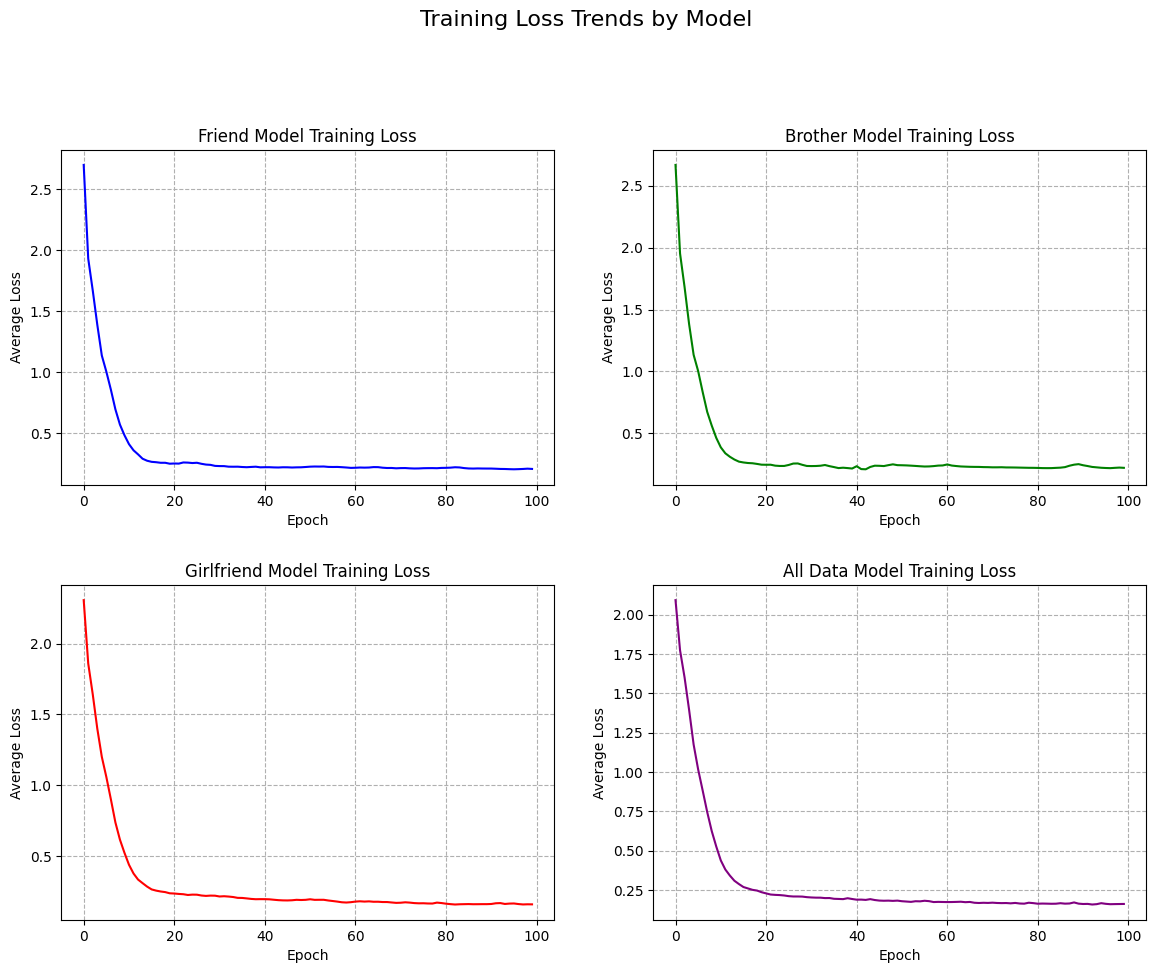

In [89]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plt.subplots_adjust(hspace=0.3)

# --- 1. Friend Model (친구 모델) ---
axes[0, 0].plot(loss_friend, label='Friend Model Loss', color='blue')
axes[0, 0].set_title('Friend Model Training Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Average Loss')
axes[0, 0].grid(True, linestyle='--')

# --- 2. Brother Model (형제 모델) ---
axes[0, 1].plot(loss_brother, label='Brother Model Loss', color='green')
axes[0, 1].set_title('Brother Model Training Loss')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Average Loss')
axes[0, 1].grid(True, linestyle='--')

# --- 3. Girlfriend Model (여자친구 모델) ---
axes[1, 0].plot(loss_girlfriend, label='Girlfriend Model Loss', color='red')
axes[1, 0].set_title('Girlfriend Model Training Loss')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Average Loss')
axes[1, 0].grid(True, linestyle='--')

# --- 4. All Data Model (전체 모델) ---
axes[1, 1].plot(loss_all, label='All Data Model Loss', color='purple')
axes[1, 1].set_title('All Data Model Training Loss')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Average Loss')
axes[1, 1].grid(True, linestyle='--')

plt.suptitle('Training Loss Trends by Model', fontsize=16, y=1.02)
plt.show()

### 4.2 챗봇 응답 생성 및 테스트

In [90]:
MODEL_PATHS = {
    '친구': './model_friend',
    '형제': './model_brother',
    '여친': './model_girlfriend',
    '전체': './model_all'
}

In [92]:
test_models = {}
test_tokenizers = {}

In [96]:
for name, path in MODEL_PATHS.items():
    test_tokenizers[name] = AutoTokenizer.from_pretrained(path)
    test_models[name] = AutoModelForCausalLM.from_pretrained(path).to(device).eval()

In [104]:
def generate_response(user_text, model, tokenizer, device):
    sent = '<usr>' + user_text + '<sys>'
    input_ids = [tokenizer.bos_token_id] + tokenizer.encode(sent, add_special_tokens=False)
    input_ids = torch.tensor([input_ids], dtype=torch.long).to(device)
    
    # 모델 응답 생성
    with torch.no_grad(): 
        output = model.generate(
            input_ids,
            max_length=50,  
            do_sample=True,
            top_k=50,
            top_p=0.95,
            temperature=0.8, 
            eos_token_id=tokenizer.eos_token_id,
            early_stopping=True
        )
    
    decoded_sentence = tokenizer.decode(output[0].tolist())
    chatbot_response = decoded_sentence.split('<sys>')[1].replace('</s>', '').strip()
    return chatbot_response

In [105]:
test_queries = [
    "오늘 저녁 뭐 먹을래?",
    "학교 때문에 너무 힘들다.",
    "카페 갈래?",
    "지금 뭐해?"
]

In [107]:
for query in test_queries:
    print(f"\n[사용자 입력] : {query}")
    response_f = generate_response(query, test_models['친구'], test_tokenizers['친구'], device)
    print(f"  [친구 모델] : {response_f}")
    
    response_b = generate_response(query, test_models['형제'], test_tokenizers['형제'], device)
    print(f"  [형제 모델] : {response_b}")
    
    response_g = generate_response(query, test_models['여친'], test_tokenizers['여친'], device)
    print(f"  [여친 모델] : {response_g}")

    response_a = generate_response(query, test_models['전체'], test_tokenizers['전체'], device)
    print(f"  [전체 모델] : {response_a}")


[사용자 입력] : 오늘 저녁 뭐 먹을래?
  [친구 모델] : 나 오늘 울산갈듯? 아 담배물었으면 엄마한테 걸릴뻔했오 노
  [형제 모델] : 오늘?
  [여친 모델] : 사진 우리 생선튀김먹을까 생각보다 너무 작 어제부터 쭉해가지구
  [전체 모델] : 나나나 오늘 학교에서서 먹고 바로 잤어!!

[사용자 입력] : 학교 때문에 너무 힘들다.
  [친구 모델] : ᄏᄏᄏᄏᄏᄏᄏᄏᄏᄏ 나도
  [형제 모델] : 어떻게을거아님?
  [여친 모델] : 언니만나서 너무덥다...
  [전체 모델] : 힝 난 운동안갈거같아서 사진 날씨면 해떨려나...

[사용자 입력] : 카페 갈래?
  [친구 모델] : ᄋᄋ 나 근데 이거하면됨
  [형제 모델] : ᄂᄂ 안끝남
  [여친 모델] : 응응 좀 멀리갔다왔어!!
  [전체 모델] : 아직 모르겠엉 유빈이 카페왔오??

[사용자 입력] : 지금 뭐해?
  [친구 모델] : 지금 그냥 보는중
  [형제 모델] : 잠만 나 지금 통화중
  [여친 모델] : 사진 모루겠너... ᄒᄒ
  [전체 모델] : 나나 커피사먹었어 지금 학교가는길!!


## 5. 결론
<hr>

### 5.1 정량적 평가 결과 및 분석

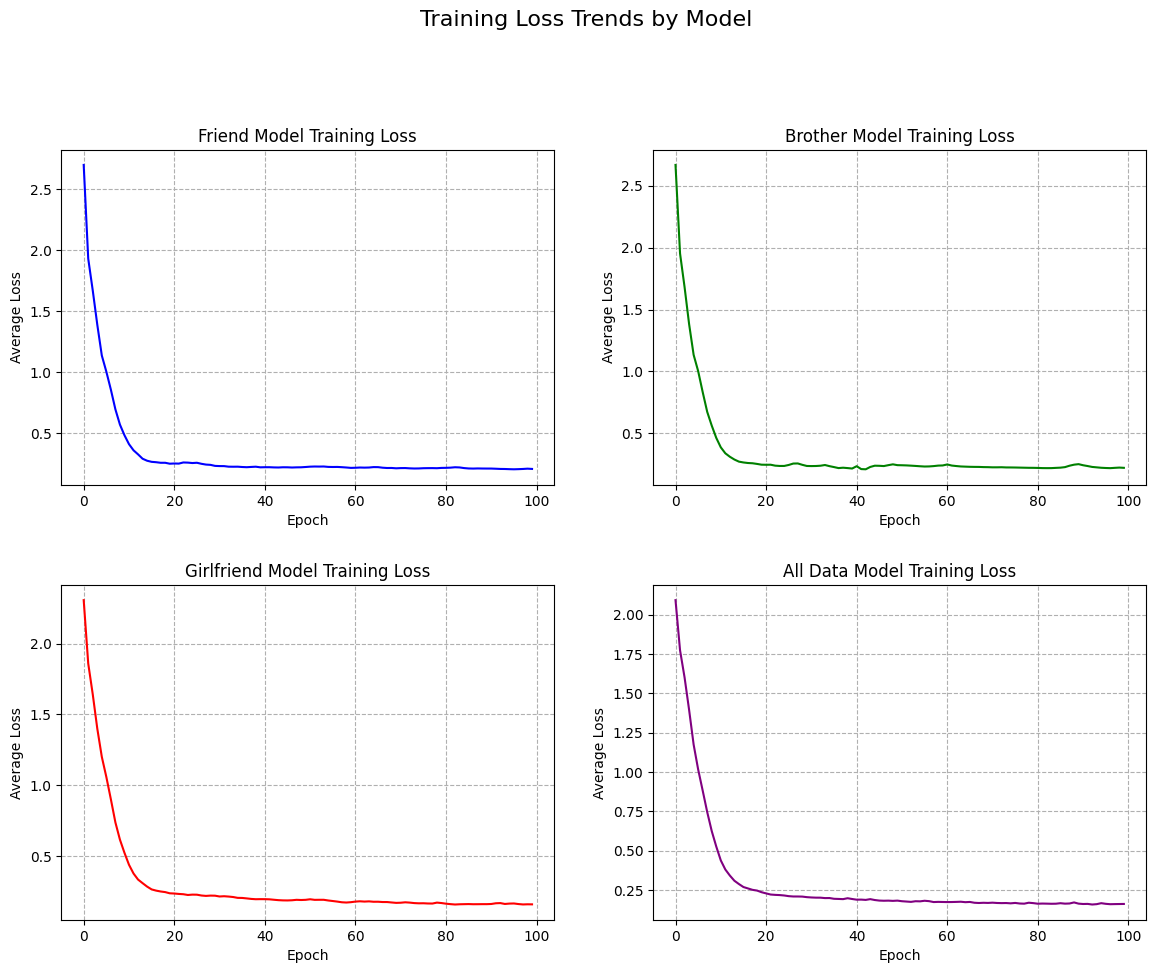

In [108]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plt.subplots_adjust(hspace=0.3)

# --- 1. Friend Model (친구 모델) ---
axes[0, 0].plot(loss_friend, label='Friend Model Loss', color='blue')
axes[0, 0].set_title('Friend Model Training Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Average Loss')
axes[0, 0].grid(True, linestyle='--')

# --- 2. Brother Model (형제 모델) ---
axes[0, 1].plot(loss_brother, label='Brother Model Loss', color='green')
axes[0, 1].set_title('Brother Model Training Loss')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Average Loss')
axes[0, 1].grid(True, linestyle='--')

# --- 3. Girlfriend Model (여자친구 모델) ---
axes[1, 0].plot(loss_girlfriend, label='Girlfriend Model Loss', color='red')
axes[1, 0].set_title('Girlfriend Model Training Loss')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Average Loss')
axes[1, 0].grid(True, linestyle='--')

# --- 4. All Data Model (전체 모델) ---
axes[1, 1].plot(loss_all, label='All Data Model Loss', color='purple')
axes[1, 1].set_title('All Data Model Training Loss')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Average Loss')
axes[1, 1].grid(True, linestyle='--')

plt.suptitle('Training Loss Trends by Model', fontsize=16, y=1.02)
plt.show()

* 4개 모델 모두 학습이 진행됨에 따라 Loss가 안정적으로 감소하는 추세를 보임.
* 모델이 과적합 없이 정상적으로 수렴하였으며, 학습 데이터에 대해 효과적으로 학습함.

### 5.2 정성적 평가 결과 및 분석

In [109]:
test_queries = [
    "오늘 저녁 뭐 먹을래?",
    "학교 때문에 너무 힘들다.",
    "카페 갈래?",
    "지금 뭐해?"
]

In [111]:
test_queries = [
    "오늘 저녁 뭐 먹을래?",
    "학교 때문에 너무 힘들다.",
    "카페 갈래?",
    "지금 뭐해?",
    "내일 시험인데 공부 안했어ㅠㅠ",
    "주말에 놀러갈래?",
    "오늘 날씨 진짜 좋다!",
    "배고파 죽겠어",
    "너 요즘 바빠?",
    "같이 영화 볼래?"
]

for query in test_queries:
    print(f"\n[사용자 입력] : {query}")
    response_f = generate_response(query, test_models['친구'], test_tokenizers['친구'], device)
    print(f"  [친구 모델] : {response_f}")
    
    response_b = generate_response(query, test_models['형제'], test_tokenizers['형제'], device)
    print(f"  [형제 모델] : {response_b}")
    
    response_g = generate_response(query, test_models['여친'], test_tokenizers['여친'], device)
    print(f"  [여친 모델] : {response_g}")
    
    response_a = generate_response(query, test_models['전체'], test_tokenizers['전체'], device)
    print(f"  [전체 모델] : {response_a}")


[사용자 입력] : 오늘 저녁 뭐 먹을래?
  [친구 모델] : 나 서울에서감 ᄏᄏ 도착하면 10시넘을듯?
  [형제 모델] : 아니면 모마 ᄀ?
  [여친 모델] : 음 일단 갈려구!!
  [전체 모델] : 나 오늘 성남에서 먹어글까...?? 성남가서 먹어글까...? ᄒᄒ

[사용자 입력] : 학교 때문에 너무 힘들다.
  [친구 모델] : 왜
  [형제 모델] : 학교 공제 우리과에서 제일 많이보는사람이
  [여친 모델] : 정신없겠는데...
  [전체 모델] : 힝 난 산책...ᄒᄒ

[사용자 입력] : 카페 갈래?
  [친구 모델] : ᄋᄋ 방금 지나가다
  [형제 모델] : ᄂᄂ 안된다 이제 ᄏᄏ
  [여친 모델] : 응 귀차타고와서 타고내려<unk>옹
  [전체 모델] : 맞엉 뭔가 사람많아서... ㅜㅜ

[사용자 입력] : 지금 뭐해?
  [친구 모델] : 내가 가서 설명해줌 나 동아리소풍 사전답사 ᄏᄏ
  [형제 모델] : 잠만 나 지금 통화중
  [여친 모델] : 사진 공부중이야...
  [전체 모델] : 나나 커피사먹었어!!

[사용자 입력] : 내일 시험인데 공부 안했어ㅠㅠ
  [친구 모델] : 좀 걸림 ᄏᄏᄏᄏᄏᄏᄏᄏ
  [형제 모델] : 안됨? ᅮ
  [여친 모델] : 오오 괜찮아!!
  [전체 모델] : 오오 졸아좋아 우리 이제 시험끝나니깐 바로 가볼게!!

[사용자 입력] : 주말에 놀러갈래?
  [친구 모델] : ᄂᄂ 집인데 ᄏᄏᄏᄏᄏᄏᄏ
  [형제 모델] : 아 괜찮아
  [여친 모델] : 웅웅 오늘은 놀러가구 내일 놀러가는중!!
  [전체 모델] : 아닝 저녁은 언제님 <unk>

[사용자 입력] : 오늘 날씨 진짜 좋다!
  [친구 모델] : 진짜로 나였음? ᄏᄏᄏᄏᄏᄏᄏᄏᄏᄏᄏ
  [형제 모델] : ᄋᄋ 나도 오늘 레전드 들음...?
  [여친 모델] : 그러니깐 짱좋다구
  [전체 모델] : 구러니깐 짱맛있겠지?? ᄒᄒ

[사용자 입력] : 배고파 죽겠어
  [친구 모델] : 2시에 먹을까
  [형제 모델] : ᄀᄀ?
 

* 10개의 질문에 대해 4개모델의 응답을 비교한 결과, 전반적으로 각 모델이 입력 질문에 대해 응답을 얼추 잘 생성하는 것을 확인할 수 있음.
* 하지만 \<unk>, 사진 등 일부 응답에서 전처리되지 않은 토큰이 포함됨.
* 또한 전체 통합 모델이 여자친구 모델의 말투와 유사하게 나오는 것을 보아 학습 데이터 분포에서 여자친구 관계 데이터의 비중이 다른 관계보다 높았기 때문으로 분석됨.

### 5.3 문제점 및 개선방향

1. 비텍스트 요소 처리의 어려움
* 카카오톡 데이터 내 이미지, 사진 등 비텍스트 요소의 형식이 대화마다 달라서 모든 데이터에 적용 가능한 일반화된 전처리 함수 구현이 어려웠음.

2. 데이터 편향 문제
* 특정 데이터(예: 여자친구 데이터)의 비중이 과도하게 높아서 통합 모델의 응답이 특정 스타일로 치우짐.
* 학습 범위를 벗어난 입력에서는 엉뚱한 응답이 발생함.

  * 데이터셋의 편향을 줄이기 위해 수집한 데이터보다 더 많이 추가로 수집하거나, 기존 데이터의 비율을 조정해서 특정 데이터가 전체 학습에 주는 영향을 줄일 필요가 있음.

* 대화 데이터 내 이미지나 사진 등 비텍스트 요소의 형식이 제각각이라 일반화시키기가 여려운데, 이를 각 데이터셋의 특성을 분석해 맞춤 처리하는 전처리 함수가 필요함.

* 추가로 KoGPT2보다 더 큰 규모의 한국어 LLM을 사용한다면 일반화 능력이 올라가 학습 범위를 벗어나는 입력에서도 엉뚱한 응답을 내는 문제를 줄일 수 있을 것 같음.